Mathew Scaria

**Research Question:** How do Vacancy Rates Affect Fair Market Rent?   
**Dependent Variable:** fmr_2bed (Rent for a 2 bedroom rental unit)   
**Independent Variable:** vacancy_rate (The percent of rental units that are vacant for rent)   
**Controls:**     
total_housing_units (Total number of rental units this includes apartments, houses, etc)   
median_income (People's Income in dollars)   
households_with_children (The number of families that have children under 18)

# Motivation:
This is an important research topic because vacancy rates and fair market rent are closely tied to housing affordability, urban development, and economic stability. Understanding this relationship can help policymakers, landlords, and renters better understand how housing markets function.

# Part 1: Webscraping From HUD API

In part one I am importing the proper packages so I can get data from the API. I also create a loop to loop through all the county data I need.

In [4]:
import requests 
import pandas as pd 
import time   

In [5]:
#I made variables out of my API Key and API Link becasue the API Key is long 
API_Key = #I removed my api key for security reasons

API_URL = "https://www.huduser.gov/hudapi/public" #This is the link to my API

#it tells the HUD server who I am and that I am authorized to access the data
headers = {
    'Authorization': f'Bearer {API_Key}', 
    'Mathew'   : 'Assignment 1'   #identifies this as my assignment
}


In [6]:
# Instead of hardcoding a list of all states, I am calling the listStates endpoint to get all state codes directly from the API
states_response = requests.get(
    API_URL + '/fmr/listStates',
    headers=headers
)

all_states = [state['state_code'] for state in states_response.json()] 

In [14]:
# Here I am trying to obtain my dependent variable which is fair market rent
# It loops through every state and grabs county-level 2-bedroom fair market rent
# fmr_2bed is my dependent variable
# I went with 2023 because the Census Bureau CSVs I use later only go up to 2023

all_fmr_records = [] #empty list to store county data I get from each state

for state in all_states: #looping through every state code in the all_states list
    fmr_response = requests.get(
        API_URL + f'/fmr/statedata/{state}', #f-string inserts the state code into the endpoint for each state
        headers=headers, #sends my API key so the server knows I am authorized
        params={'year': 2023} #This lets me get 2023 data
    )

    fmr_data = fmr_response.json() #converts the raw API response into a Python object I can work with

    #For this for loop I had assistance from claude AI
    for county in fmr_data['data']['counties']: #each state has multiple counties so I loop through them
        all_fmr_records.append({ #adding each county as a dictionary to my list
            'fips_code'  : county.get('fips_code'),   # unique county identifier
            'county_name': county.get('county_name'), # name of the county
            'state'      : state,                     # state the county belongs to, theres no get b/c I've done that above
            'fmr_2bed'   : county.get('Two-Bedroom')  # this is my dependent variable
        })

    time.sleep(0.5) # pausing 0.5 seconds between each request so I don't overwhelm the API server

fmr_df = pd.DataFrame(all_fmr_records) # converting my list of records into a pandas dataframe

# county level fips codes have 5 digits
# the API returns fips codes with extra unnecessary digits at the end so I trim to 5 to match Census data
fmr_df['fips_code'] = fmr_df['fips_code'].str[:5] # Lets me keep only the first 5 characters of the fips code
fmr_df.head() #check first few rows to confirm data looks correct

,fips_code,county_name,state,fmr_2bed
0,01001,Autauga County,AL,977
1,01003,Baldwin County,AL,1206
2,01005,Barbour County,AL,740
3,01007,Bibb County,AL,1075
4,01009,Blount County,AL,1075


# Part 2: Cleaning the data and finalizing the final CSV

In Part 2 I am grabbing all the variables I need from the csv files I obtained from the Census Bureau. 

In [8]:
# The CSV that I found is from the census the file is in the Final Assignment folder
# I skipped row 1 because its just a description row, and usecols grabs only the columns I need
income_df = pd.read_csv('ACSDT5Y2023.B19013-Data.csv', header=1, usecols=[0, 2]) #header=1 skips the description row, usecols grabs only geo_id and median_income, Source: Census Bureau ACS 5-Year 2023
income_df.columns = ['geo_id', 'median_income'] # I am renaming columns here so its easier to read
# This CSV has a GEO ID so I want to extract the FIPS code from the geo_id column
income_df['fips_code'] = income_df['geo_id'].str[-5:] #I used -5 here because it allows me to grab digits from the right and this is because the fips code was the last 5 digits of the GEO ID
income_df = income_df[income_df['median_income'] != '-'] #the Census uses '-' as a placeholder for missing data, removing those rows so astype(int) doesn't crash
income_df['median_income'] = income_df['median_income'].astype(int) #converting to integer because median income is reported as whole dollars by the Census
income_df = income_df[['fips_code', 'median_income']] #keeping only the two columns I need for the merge

print(f"Number of obs: {income_df.shape[0]}") #print how many counties have income data
income_df.head() #check first few rows to confirm data looks correct

Number of obs: 3220


,fips_code,median_income
0,01001,69841
1,01003,75019
2,01005,44290
3,01007,51215
4,01009,61096


In [9]:
# The vacancy data that I got is a CSV from the Census and its in the final project folder
# I'm skipping the first row again because it just has descriptions, and usecols grabs only the columns I need
vacancy_df = pd.read_csv('Vacany.csv', header=1, usecols=[0, 2]) #header=1 skips the description row, usecols grabs only geo_id and total_vacant, Source: Census Bureau ACS 5-Year 2023
vacancy_df.columns = ['geo_id', 'total_vacant'] # I am renaming columns here so its easier to read
vacancy_df['fips_code'] = vacancy_df['geo_id'].str[-5:] # grabbing the last 5 digits of geo_id because the FIPS code is always the last 5 digits Source: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.contains.html
vacancy_df['total_vacant'] = vacancy_df['total_vacant'].astype(int) #converting to integer because vacant units are whole numbers
vacancy_df = vacancy_df[['fips_code', 'total_vacant']]
#Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html

# I'm loading a second Census CSV (ACS table B25002) which has total housing units per county
# I need this because the correct vacancy rate formula divides total vacant units by total housing units
# My Vacany.csv only has vacant unit breakdowns so I need this extra file for the denominator
housing_df = pd.read_csv('ACSDT5Y2023.B25002-Data.csv', header=1, usecols=[0, 2]) #Source: Census Bureau ACS 5-Year 2023
housing_df.columns = ['geo_id', 'total_housing_units'] # I am renaming columns here so its easier to read
housing_df['fips_code'] = housing_df['geo_id'].str[-5:]
housing_df['total_housing_units'] = housing_df['total_housing_units'].astype(int) #this would be an interger value
housing_df = housing_df[['fips_code', 'total_housing_units']]

# I'm merging the housing units data into my vacancy dataframe by FIPS code
# so that each county now has both total_vacant and total_housing_units in one place
vacancy_df = vacancy_df.merge(housing_df, on='fips_code') #I am merging the data on the fips code
print(vacancy_df.shape) #checking shape after merge to verify no unexpected row loss
vacancy_df.head() #checking first few rows to confirm merge looks correct

#vacancy_rate = (total_vacant / total_housing_units) * 100
#This measures what percent of ALL housing units in the county are vacant
vacancy_df['vacancy_rate'] = (vacancy_df['total_vacant'] / vacancy_df['total_housing_units']) * 100 #how I made my calculate variable it automatically saves as a float
vacancy_df = vacancy_df[['fips_code', 'total_vacant', 'total_housing_units', 'vacancy_rate']] 
 #keeping only the columns I need and dropping any rows where vacancy rate couldn't be calculated Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html

# I'm loading the households with children data from ACS table B11003
# I only need column 6 (B11003_003E) which is the number of families with children under 18
children_df = pd.read_csv('Householdswithchildren.csv', header=1, usecols=[0, 6]) #Source: Census Bureau ACS 5-Year 2023
children_df.columns = ['geo_id', 'households_with_children'] # I am renaming columns here so its easier to read
children_df['fips_code'] = children_df['geo_id'].str[-5:]
children_df['households_with_children'] = children_df['households_with_children'].astype(int)
children_df = children_df[['fips_code', 'households_with_children']]

# I'm merging the households with children data into my vacancy dataframe by FIPS code
vacancy_df = vacancy_df.merge(children_df, on='fips_code') #merging on fips_code so each county gets its households_with_children value Source: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.merge.html
print(f"Counties in dataset: {vacancy_df.shape[0]}") #print how many counties are in the dataset after all merges
vacancy_df.head() #check first few rows to confirm merge looks correct Source: https://www.w3schools.com/python/pandas/ref_df_head.asp

(3222, 3)
Counties in dataset: 3222


,fips_code,total_vacant,total_housing_units,vacancy_rate,households_with_children
0,01001,2208,24731,8.928066,5155
1,01003,33876,128518,26.358954,16692
2,01005,2622,11702,22.406426,962
3,01007,1519,9090,16.710671,1187
4,01009,2816,24793,11.358045,4405


In [10]:
# I am merging all the data from the previous cells and I am matching all this data by the FIPS code
merged_df = fmr_df.merge(vacancy_df, on='fips_code')
print(merged_df.shape) #check shape after merge to verify no unexpected row loss
merged_df.head() #check first few rows to confirm merge looks correct

merged_df = merged_df.merge(income_df, on='fips_code')
print(merged_df.shape) #check shape after merge to verify no unexpected row loss

# I'm just keeping the columns I want in my final dataset
merged_df = merged_df[['fips_code', 'county_name', 'state',
                        'fmr_2bed', 'vacancy_rate', 'total_housing_units', 
                        'median_income', 'households_with_children']]

# Dropping duplicates in case any counties got counted more than once
merged_df = merged_df.drop_duplicates(subset='fips_code', keep='first')

print(f"Final dataset: {merged_df.shape[0]} counties across {merged_df['state'].nunique()} states")
merged_df[['fmr_2bed', 'vacancy_rate', 'total_housing_units', 
           'median_income', 'households_with_children']].describe() #this lets me create a descriptive stats table

(4588, 8)
(4586, 9)
Final dataset: 3211 counties across 51 states


,fmr_2bed,vacancy_rate,total_housing_units,median_income,households_with_children
count,3211.000000,3211.000000,3.211000e+03,3211.000000,3211.000000
mean,965.336967,17.051974,4.433857e+04,64967.439738,7157.621925
std,299.714342,10.349428,1.317394e+05,18342.356782,22535.901516
min,444.000000,1.706558,4.700000e+01,16170.000000,0.000000
25%,795.000000,9.513957,5.339500e+03,54097.000000,652.500000
50%,858.000000,15.010917,1.237500e+04,63128.000000,1583.000000
75%,1024.500000,21.602721,3.085650e+04,73083.000000,4475.000000
max,3293.000000,77.316017,3.624084e+06,178707.000000,594569.000000


In [11]:
#The is the end of my project I saved all this data into a csv and it is in the final project folder
#Source: https://www.geeksforgeeks.org/python/export-pandas-dataframe-to-a-csv-file/
merged_df.to_csv('FinalProjectdataset.csv', index=False) #I set index to false because if I set it to true I'd get an extra column at the beginning of my CSV that just counts the rows, which I don't need
print(f"Number of Rows and Columns: {merged_df.shape}") #I wanted to see how many rows and columns I have

Number of Rows and Columns: (3211, 8)


# Part 3: Graphing   
Im creating 2 graphs

In [12]:
import matplotlib.pyplot as plt #this let you make graphs
import seaborn as sns #seaborn lets you add more to your graphs to make them for detailed

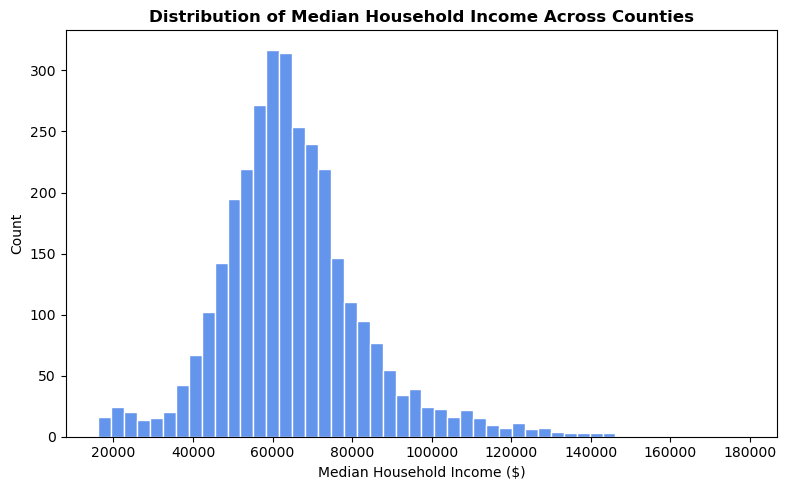

In [13]:
# Graph 1: Histogram of Median Income
fig = plt.figure(figsize=(8, 5)) #create the figure and set the size to 8 wide and 5 tall
plt.hist(merged_df['median_income'], bins=50, color='cornflowerblue', edgecolor='white') #create a histogram of median_income with 50 bins, blue bars and white edges between bars
plt.xlabel('Median Household Income ($)') #label for the x-axis
plt.ylabel('Count') #label for the y-axis
plt.title('Distribution of Median Household Income Across Counties', fontweight='bold') #title of the graph 
plt.ticklabel_format(axis='x', style='plain') #displaying x-axis numbers as plain numbers instead of scientific notation
fig.tight_layout() #auto adjusting the layout so nothing gets cut off
plt.show() #display the graph

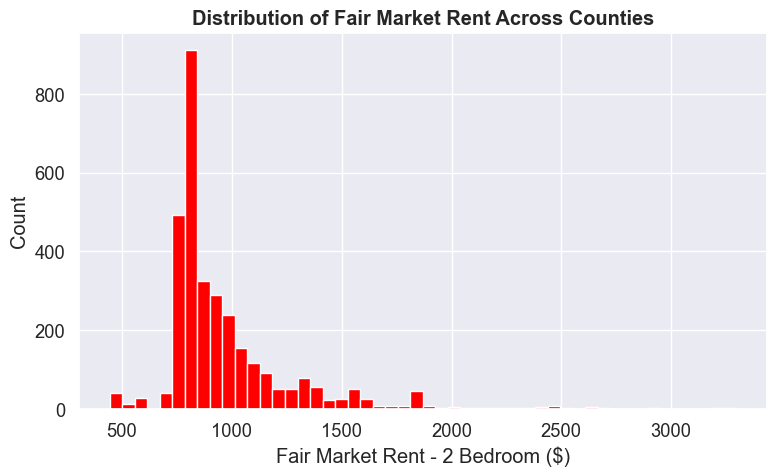

In [36]:
# Graph 2: Histogram of Fair Market Rent
fig = plt.figure(figsize=(8, 5)) #create the figure and set the size to 8 wide and 5 tall
plt.hist(merged_df['fmr_2bed'], bins=50, color='red', edgecolor='white') #create a histogram of fmr_2bed with 50 bins, red bars and white edges between bars
plt.xlabel('Fair Market Rent - 2 Bedroom ($)') #THis is the label for my x-axis in the histogram
plt.ylabel('Count') #THis is the label for my y-axis in the histogram
plt.title('Distribution of Fair Market Rent Across Counties', fontweight='bold') #THis is the title for my histogram
plt.ticklabel_format(axis='y', style='plain') #display y-axis numbers as plain numbers instead of scientific notation
fig.tight_layout()  #auto adjusting the layout so nothing gets cut off
plt.show() #display the graph